<a href="https://colab.research.google.com/github/ElizabethFrankWebb/USRI-2026/blob/main/Individual_based_model_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as ns

In [50]:
initial_population_central_deme = 300
loci = 5
selection = 2
carrying_capacity_per_deme = 300
gradient_trait_min = 0 # Minimum optimal trait value for the gradient
gradient_trait_max = 25 # Maximum optimal trait value for the gradient
optimal_growth_rate_per_deme = 1.025
mutation_rate = 10**-6
generation = 5000
migration_probality = 1/2
num_demes = 250



In [51]:
#definitions

def deme_location(num_demes, initial_population_central_deme_param, carrying_capacity_per_deme, optimal_growth_rate_per_deme, loci, gradient_trait_min, gradient_trait_max):
  demes_list = []
  central_deme_index = num_demes // 2 # Calculate the index of the central deme
  for i in range(num_demes):
    # Calculate optimal_trait_value as a gradient across demes
    optimal_trait_value = gradient_trait_min + (gradient_trait_max - gradient_trait_min) * (i / (num_demes - 1))

    # Set population and genotypes based on whether it's the central deme
    if i == central_deme_index:
      current_population_size = initial_population_central_deme_param
      current_genotypes = np.zeros((initial_population_central_deme_param, loci))
    else:
      current_population_size = 0
      current_genotypes = np.empty((0, loci)) # Empty array for no population

    deme = {
        'id': i,
        'population_size': current_population_size,
        'carrying_capacity': carrying_capacity_per_deme,
        'optimal_growth_rate': optimal_growth_rate_per_deme,
        'optimal_trait_value': optimal_trait_value, # Assign the gradient value
        'neighbors': [],
        'genotypes': current_genotypes
    }
    # Determine neighbors for a 1D arrangement (side-by-side)
    if i > 0:
      deme['neighbors'].append(i - 1);
    if i < num_demes - 1:
      deme['neighbors'].append(i + 1);
    demes_list.append(deme)
  return demes_list

enviormental_gradient_optimum = (gradient_trait_max - gradient_trait_min) / (num_demes - 1)
r_star = optimal_growth_rate_per_deme
p = migration_probality

# Calculate B
if (2 * selection * migration_probality) != 0:
    effective_enviormental_gradient = (enviormental_gradient_optimum * np.sqrt(r_star)) / (2 * selection * migration_probality)


def calculate_trait_z(individual_genotype):
  trait_value = np.sum(individual_genotype)
  return trait_value


def calculate_fitness(trait_values, optimal_trait_value, selection, current_population_size, carrying_capacity, optimal_growth_rate):
  trait_values = np.asarray(trait_values)

  if current_population_size == 0:
      return np.array([]) # No fitness for empty population

  genetic_fitness = np.exp(optimal_growth_rate * ((1 - current_population_size / carrying_capacity) - (trait_values - optimal_trait_value)**2 / (2 * selection)))

  return np.maximum(0, genetic_fitness)


def recombine(parent1_genotype, parent2_genotype, loci):
  """Performs 50% inheritance recombination between two parent genotypes."""
  offspring_genotype = np.zeros(loci)
  for i in range(loci):
    if np.random.rand() < 0.5: # 50% chance to inherit from parent1
      offspring_genotype[i] = parent1_genotype[i]
    else:
      offspring_genotype[i] = parent2_genotype[i]
  return offspring_genotype


def mutate(individual, mutation_rate):
  mutated_individual = individual.copy()
  mutated_loci_info = []
  for locus in range(len(individual)):
    if np.random.rand() < mutation_rate:
      original_value = individual[locus]
      new_value = np.random.normal(0,1)
      mutated_individual[locus] = new_value
      mutated_loci_info.append((locus, original_value, new_value))
  return mutated_individual, mutated_loci_info


def migrate_individuals(demes_list, migration_probability):
    new_demes_list = []
    # Initialize lists to temporarily hold genotypes for each deme
    # These will be populated with non-migrating individuals and incoming migrants
    temp_deme_genotypes = [[] for _ in range(len(demes_list))]

    for i, deme in enumerate(demes_list):
        current_deme_genotypes = deme['genotypes']
        # Individuals who stay in their current deme
        staying_individuals = []

        for individual_genotype in current_deme_genotypes:
            if np.random.rand() < migration_probability:
                # Individual attempts to migrate
                if deme['neighbors']: # Check if there are any neighbors to migrate to
                    # Choose a random neighbor
                    target_deme_id = np.random.choice(deme['neighbors'])
                    temp_deme_genotypes[target_deme_id].append(individual_genotype)
                else:
                    # No neighbors, individual stays in current deme
                    staying_individuals.append(individual_genotype)
            else:
                # Individual does not migrate, stays in current deme
                staying_individuals.append(individual_genotype)

        temp_deme_genotypes[i].extend(staying_individuals)

    # Reconstruct the demes_list with updated genotypes and population sizes
    for i, deme in enumerate(demes_list):
        updated_genotypes_for_deme = np.array(temp_deme_genotypes[i])
        if updated_genotypes_for_deme.ndim == 1 and len(updated_genotypes_for_deme) > 0:
            updated_genotypes_for_deme = updated_genotypes_for_deme.reshape(-1, demes_list[0]['genotypes'].shape[1])
        elif len(updated_genotypes_for_deme) == 0:
            updated_genotypes_for_deme = np.empty((0, demes_list[0]['genotypes'].shape[1]))

        new_deme = deme.copy()
        new_deme['genotypes'] = updated_genotypes_for_deme
        new_deme['population_size'] = len(updated_genotypes_for_deme)
        new_demes_list.append(new_deme)

    return new_demes_list

In [52]:
#simulation loop

all_individual_fitness_history = [] # List of arrays, each array containing all individual fitness values across all demes for a generation
average_deme_fitness_history = [] # List of arrays, each array containing average fitness per deme for a generation
trait_value_history = [] # List of arrays, each array containing all individual trait values across all demes for a generation

# Assinging Demes
demes_list = deme_location(num_demes, initial_population_central_deme, carrying_capacity_per_deme, optimal_growth_rate_per_deme, loci, gradient_trait_min, gradient_trait_max)

for g in range(generation):
    # 1. Migration Step
    demes_list = migrate_individuals(demes_list, migration_probality)

    # Prepare for the next generation's demes and to collect current generation's data
    next_gen_demes_list = []
    current_generation_individual_fitness = []
    current_generation_deme_averages = []
    current_generation_individual_trait_values = []

    for i, deme in enumerate(demes_list):
        current_genotypes = deme['genotypes']
        current_pop_size = deme['population_size']

        # Initialize next_gen_deme for this iteration (copy current properties)
        next_gen_deme = deme.copy()
        next_gen_genotypes_list_for_deme = []

        if current_pop_size == 0:
            # If deme is extinct, no processing, add empty data to history and continue
            current_generation_deme_averages.append(0.0) # Store 0 for extinct deme's average fitness
            next_gen_deme['genotypes'] = np.empty((0, loci))
            next_gen_deme['population_size'] = 0
            next_gen_demes_list.append(next_gen_deme)
            continue

        # 2. Calculate Trait Values and Fitness
        trait_values = np.array([calculate_trait_z(individual) for individual in current_genotypes])
        population_fitness = calculate_fitness(trait_values,
                                               deme['optimal_trait_value'], # Use deme-specific optimal_trait_value
                                               selection,
                                               current_pop_size,
                                               deme['carrying_capacity'],
                                               deme['optimal_growth_rate'])

        # Handle local extinction due to zero fitness
        if np.all(population_fitness == 0) or np.sum(population_fitness) == 0:
            current_generation_deme_averages.append(0.0) # Store 0 for extinct deme's average fitness
            next_gen_deme['genotypes'] = np.empty((0, loci))
            next_gen_deme['population_size'] = 0
            next_gen_demes_list.append(next_gen_deme)
            continue

        # Store current generation's individual fitness and trait values for this deme
        current_generation_individual_fitness.append(population_fitness)
        current_generation_deme_averages.append(np.mean(population_fitness))
        current_generation_individual_trait_values.append(trait_values)

        # 3. Parent Selection and Offspring Generation
        probabilities = population_fitness / np.sum(population_fitness)
        total_offspring_to_generate = int(np.sum(population_fitness))

        if total_offspring_to_generate == 0:
            next_gen_deme['genotypes'] = np.empty((0, loci))
            next_gen_deme['population_size'] = 0
            next_gen_demes_list.append(next_gen_deme)
            continue

        individual_indices = np.arange(current_pop_size)

        for _ in range(total_offspring_to_generate):
            # Select two parents based on their fitness probabilities
            chosen_parent_indices = np.random.choice(
                individual_indices,
                size=2,
                p=probabilities,
                replace=True
            )
            parent1_genotype = current_genotypes[chosen_parent_indices[0]]
            parent2_genotype = current_genotypes[chosen_parent_indices[1]]

            # Perform recombination
            offspring_genotype_recombined = recombine(parent1_genotype, parent2_genotype, loci)

            # Apply mutation
            mutated_individual, _ = mutate(offspring_genotype_recombined, mutation_rate)
            next_gen_genotypes_list_for_deme.append(mutated_individual)

        # Update the deme for the next generation
        if next_gen_genotypes_list_for_deme:
            next_gen_deme['genotypes'] = np.array(next_gen_genotypes_list_for_deme)
        else:
            next_gen_deme['genotypes'] = np.empty((0, loci))
        next_gen_deme['population_size'] = len(next_gen_deme['genotypes'])
        next_gen_demes_list.append(next_gen_deme)

    # After processing all demes for the current generation
    demes_list = next_gen_demes_list

    # Store the aggregated fitness and trait values for the entire generation
    all_individual_fitness_history.append(np.concatenate([f for f in current_generation_individual_fitness if f.size > 0]) if any(f.size > 0 for f in current_generation_individual_fitness) else np.array([]))
    average_deme_fitness_history.append(np.array(current_generation_deme_averages))
    trait_value_history.append(np.concatenate([tv for tv in current_generation_individual_trait_values if tv.size > 0]) if any(tv.size > 0 for tv in current_generation_individual_trait_values) else np.array([]))

Population went extinct before or at Generation 5000. No individual fitness data to plot.
Population went extinct before or at Generation 5000. No trait value data to plot.


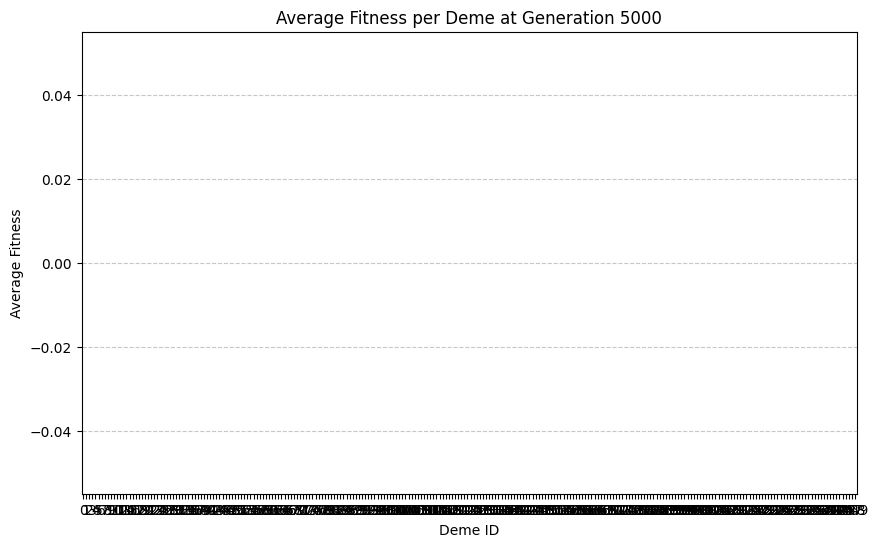

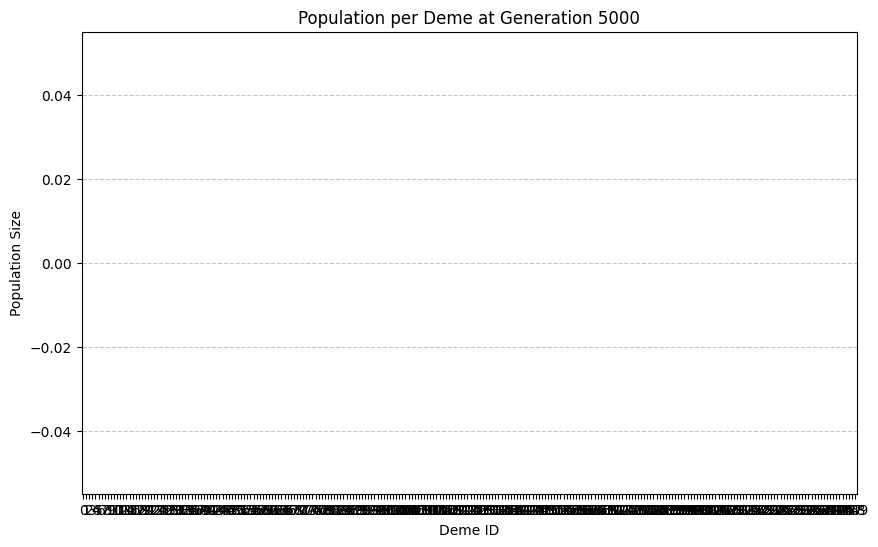

In [53]:
#graphs

# Individual Fitness Distribution across all demes
if all_individual_fitness_history and all_individual_fitness_history[-1].size > 0:
    final_generation_individual_fitness = all_individual_fitness_history[-1]
    plt.figure(figsize=(8, 6))
    ns.histplot(data=final_generation_individual_fitness, bins=10, kde=True, color="lightblue")
    ns.rugplot(x=final_generation_individual_fitness, color="darkblue", height=0.05)
    plt.title(f"Individual Fitness Distribution (All Demes) at Generation {generation}")
    plt.xlabel("Fitness Value")
    plt.ylabel("Frequency")
    plt.show()
else:
    print(f"Population went extinct before or at Generation {generation}. No individual fitness data to plot.")

# Individual Trait Value Distribution across all demes
if trait_value_history and trait_value_history[-1].size > 0:
    final_generation_trait_value = trait_value_history[-1]
    plt.figure(figsize=(8, 6))
    ns.histplot(data=final_generation_trait_value, bins=10, kde=True, color="lightblue")
    ns.rugplot(x=final_generation_trait_value, color="darkblue", height=0.05)
    plt.title(f"Individual Trait Value Distribution (All Demes) at Generation {generation}")
    plt.xlabel("Trait Value")
    plt.ylabel("Frequency")
    plt.show()
else:
    print(f"Population went extinct before or at Generation {generation}. No trait value data to plot.")

# Average Fitness per Deme
if average_deme_fitness_history and average_deme_fitness_history[-1].size > 0:
    final_generation_average_deme_fitness = average_deme_fitness_history[-1]
    deme_ids = np.arange(len(final_generation_average_deme_fitness))

    plt.figure(figsize=(10, 6))
    ns.barplot(x=deme_ids, y=final_generation_average_deme_fitness, color='skyblue')
    plt.title(f"Average Fitness per Deme at Generation {generation}")
    plt.xlabel("Deme ID")
    plt.ylabel("Average Fitness")
    plt.xticks(deme_ids) # Ensure all deme IDs are shown on the x-axis
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print(f"Population went extinct before or at Generation {generation}. No average fitness per deme data to plot.")

# Population in each deme
# Extract population sizes for the final generation from demes_list
final_population_deme = [deme['population_size'] for deme in demes_list]

if final_population_deme:
    plt.figure(figsize=(10, 6))
    ns.barplot(x=deme_ids, y=final_population_deme, color='skyblue')
    plt.title(f"Population per Deme at Generation {generation}")
    plt.xlabel("Deme ID")
    plt.ylabel("Population Size") # Corrected y-axis label
    plt.xticks(deme_ids) # Ensure all deme IDs are shown on the x-axis
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print(f"No population data to plot for Generation {generation}.")